In [1]:
# =============================================================
#  generar_figuras.py
#  Genera las dos figuras del artículo técnico (UNIR - Act. 2)
#  a partir del CSV de MoMo descargado del ISCIII.
#
#  Uso:
#    python generar_figuras.py
#
#  Salida:
#    figura1_serie_temporal.pdf
#    figura2_regresion.pdf
#
#  Requisitos:
#    pip install pandas matplotlib numpy
# =============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

In [2]:
# -------------------------------------------------------------
# 0. CONFIGURACIÓN GENERAL DE ESTILO
# -------------------------------------------------------------
plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        10,
    'axes.titlesize':   10,
    'axes.labelsize':   10,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'legend.fontsize':  8,
    'figure.dpi':       150,
    'axes.grid':        True,
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
})
 
AZUL  = '#005AA6'   # color principal (azul UNIR)
ROJO  = '#C0392B'   # color secundario (atribuibles / verano 2025)
NEGRO = '#2C2C2C'

In [3]:
# -------------------------------------------------------------
# 1. CARGA Y PREPARACIÓN DE DATOS
# -------------------------------------------------------------
# Ajusta la ruta si el CSV no está en la misma carpeta que este script
RUTA_CSV = 'mortalidad_verano_2024_2025.csv'
 
df = pd.read_csv(RUTA_CSV, sep=';')
df = df.sort_values('fecha').reset_index(drop=True)
df['indice'] = df.index + 1  # posición 1..72 para el eje X
 
# Etiquetas legibles para el eje X de la serie temporal
# Seleccionamos 9 posiciones representativas
TICKS_IDX    = [1, 10, 19, 27, 33, 39, 46, 55, 65, 72]
TICKS_LABEL  = [
    'S20/24', 'S29/24', 'S38/24',
    'S46/24', 'S52/24', 'S06/25',
    'S13/25', 'S22/25', 'S32/25', 'S39/25'
]
 
# Subconjunto verano (semanas 22-39 de cada año)
def es_verano(fecha):
    return 22 <= int(fecha.split('-')[1]) <= 39
 
mask_verano = df['fecha'].apply(es_verano)
df_verano   = df[mask_verano].copy()
v2024       = df_verano[df_verano['fecha'].str.startswith('2024')]
v2025       = df_verano[df_verano['fecha'].str.startswith('2025')]

In [4]:
# -------------------------------------------------------------
# 2. CÁLCULO DE LA REGRESIÓN LINEAL
# -------------------------------------------------------------
x = df_verano['atribuibles_temperatura'].values.astype(float)
y = df_verano['exceso_todas_causas'].values.astype(float)
n = len(x)
 
xm  = x.mean()
ym  = y.mean()
b1  = np.sum((x - xm) * (y - ym)) / np.sum((x - xm) ** 2)
b0  = ym - b1 * xm
y_hat   = b0 + b1 * x
ss_res  = np.sum((y - y_hat) ** 2)
ss_tot  = np.sum((y - ym) ** 2)
r2      = 1 - ss_res / ss_tot
 
print(f'Regresión: ŷ = {b0:.2f} + {b1:.4f}·x   |   R² = {r2:.4f}   |   n = {n}')

Regresión: ŷ = 10.37 + 1.0736·x   |   R² = 0.5753   |   n = 36


✓ figura1_serie_temporal.pdf guardada


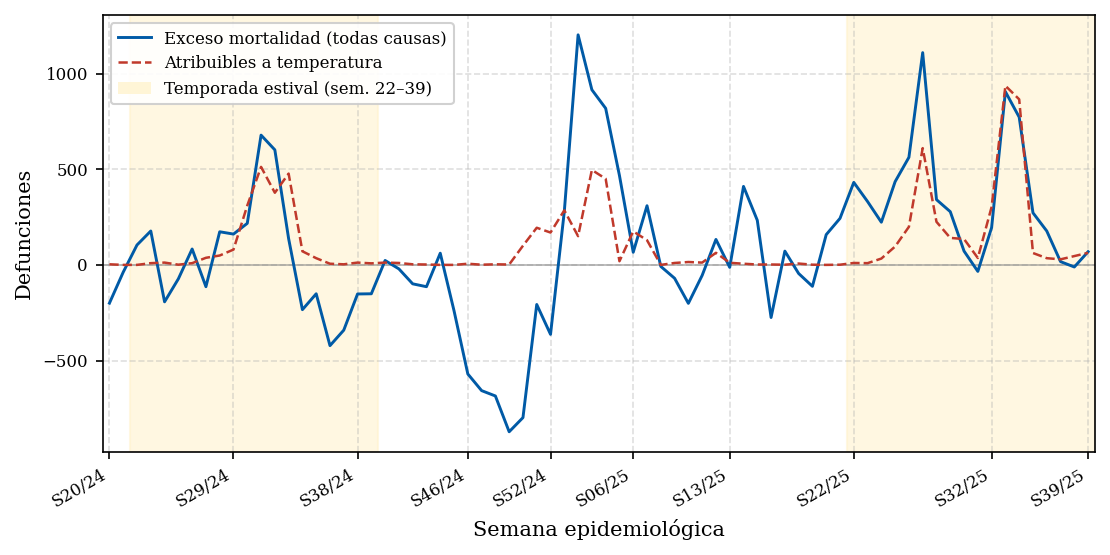

In [8]:
# -------------------------------------------------------------
# 3. FIGURA 1 — SERIE TEMPORAL
# -------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(7.5, 3.8))
 
# Línea de referencia en 0
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='-', alpha=0.6)
 
# Sombreado de las temporadas estivales
for anio in ['2024', '2025']:
    bloque = df[df['fecha'].str.startswith(anio) & mask_verano]
    if not bloque.empty:
        x0 = bloque['indice'].iloc[0] - 0.5
        x1 = bloque['indice'].iloc[-1] + 0.5
        ax1.axvspan(x0, x1, color='#FFF3CD', alpha=0.6)
 
# Serie exceso mortalidad
ax1.plot(df['indice'], df['exceso_todas_causas'],
         color=AZUL, linewidth=1.4, label='Exceso mortalidad (todas causas)')
 
# Serie atribuibles temperatura
ax1.plot(df['indice'], df['atribuibles_temperatura'],
         color=ROJO, linewidth=1.2, linestyle='--',
         label='Atribuibles a temperatura')
 
# Ejes y etiquetas
ax1.set_xlabel('Semana epidemiológica')
ax1.set_ylabel('Defunciones')
ax1.set_xlim(0.5, len(df) + 0.5)
ax1.set_xticks(TICKS_IDX)
ax1.set_xticklabels(TICKS_LABEL, rotation=30, ha='right')
 
# Leyenda con el sombreado
patch_verano = plt.Rectangle((0, 0), 1, 1, fc='#FFF3CD', alpha=0.8)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles=handles + [patch_verano],
    labels=labels + ['Temporada estival (sem. 22–39)'],
    loc='upper left', framealpha=0.9
)
 
fig1.tight_layout()
fig1.savefig('figura1_serie_temporal.pdf', bbox_inches='tight')
fig1.savefig('figura1_serie_temporal.png', bbox_inches='tight', dpi=200)
print('✓ figura1_serie_temporal.pdf guardada')

In [6]:
# -------------------------------------------------------------
# 4. FIGURA 2 — DIAGRAMA DE DISPERSIÓN + RECTA DE REGRESIÓN
# -------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(6.5, 4.2))
 
# Puntos verano 2024
ax2.scatter(
    v2024['atribuibles_temperatura'],
    v2024['exceso_todas_causas'],
    color=AZUL, marker='o', s=40, alpha=0.8,
    label='Verano 2024', zorder=3
)
 
# Puntos verano 2025
ax2.scatter(
    v2025['atribuibles_temperatura'],
    v2025['exceso_todas_causas'],
    color=ROJO, marker='s', s=40, alpha=0.8,
    label='Verano 2025', zorder=3
)
 
# Recta de regresión
x_line = np.linspace(0, x.max() * 1.05, 200)
y_line = b0 + b1 * x_line
ax2.plot(x_line, y_line, color=NEGRO, linewidth=1.5,
         label=f'Regresión: $\\hat{{Y}} = {b0:.1f} + {b1:.3f}\\,X$\n$R^2 = {r2:.2f}$, $n = {n}$')
 
# Línea horizontal en 0
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='-', alpha=0.5)
 
ax2.set_xlabel('Defunciones atribuibles a temperatura')
ax2.set_ylabel('Exceso de mortalidad (todas causas)')
ax2.legend(loc='upper left', framealpha=0.9)
 
fig2.tight_layout()
fig2.savefig('figura2_regresion.pdf', bbox_inches='tight')
fig2.savefig('figura2_regresion.png', bbox_inches='tight', dpi=200)
print('✓ figura2_regresion.pdf guardada')
 
plt.close('all')
print('\nListo. Archivos generados:')
print('  figura1_serie_temporal.pdf / .png')
print('  figura2_regresion.pdf      / .png')

✓ figura2_regresion.pdf guardada

Listo. Archivos generados:
  figura1_serie_temporal.pdf / .png
  figura2_regresion.pdf      / .png


In [10]:
# Tabla estadísticos descriptivos
for nombre, v in [('Verano 2024', v2024), ('Verano 2025', v2025)]:
    n     = len(v)
    media = v['exceso_todas_causas'].mean()
    de    = v['exceso_todas_causas'].std(ddof=1)   # ddof=1 → desviación típica muestral
    total = v['atribuibles_temperatura'].sum()
    print(f'{nombre}: n={n}, media={media:.1f}, DE={de:.1f}, total={total}')
    

Verano 2024: n=18, media=27.8, DE=292.2, total=2008
Verano 2025: n=18, media=341.3, DE=320.5, total=3833
